<a href="https://colab.research.google.com/github/swastiksardaronlineclass-web/Lab-Assignment-N1/blob/main/Data_preprocessing_and_Cleaning_Steps_using_sample_Dataset_CSE_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem: You have been given a dataset in Excel format, for an example, a sample dataset in the healthcare domain is given. Now you have to perform below task:

# Problem 1: Working in a Jupyter/IDE in a Python environment, using NumPy and Pandas to import CSV/Excel dataset and perform basic data operations.

# Problem 2: Handling missing values; null values; duplicate values; data cleaning; feature selection; train—test split; visualization using Matplotlib and EDA operations on the same dataset.


**Please Note: Dataset may be as per your choice and according to your requirement just for an example here we choose Sample Dataset (stroke dataset) from medical/healthcare domain. You may choose your own domain dataset but basic Data Preprocessing and Cleaning operations will remain same. As and when required, you need to change your Colab Python code as per your requirement and functions/operations you want to do in near future.**



# Step by Step Procedure to Solve This problem:

# Sample Dataset — EDA, Preprocessing & Feature Selection


**Run this notebook top-to-bottom in Google Colab.**

Pipeline covered:
1. Install & import libraries
2. Upload the dataset
3. Initial exploration
4. Handle missing / null values
5. Handle duplicate values
6. Exploratory Data Analysis (EDA) & visualization
7. Data normalization (numerical scaling + categorical encoding)
8. Correlation analysis
9. Feature selection & feature ranking
10. Train-test split (80:20)




## 1. Install & import libraries
Colab already ships with these, but running this once ensures the right versions are present.

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.1.3
Pandas version: 2.2.3


## 2. Upload the dataset

Run the cell below, then click **Choose Files** and select `sample_dataset.xlsx`
from your computer. (If your file already lives in Google Drive instead, use the
commented-out `drive.mount(...)` block below it.)

In [2]:
from google.colab import files
uploaded = files.upload()   # select stroke_sample_dataset.xlsx when prompted

filename = list(uploaded.keys())[0]
print("Uploaded:", filename)

# --- Alternative: load from Google Drive instead of uploading each time ---
# from google.colab import drive
# drive.mount('/content/drive')
# filename = "/content/drive/MyDrive/sample_dataset.xlsx"


Saving sample_dataset.xlsx to sample_dataset.xlsx
Uploaded: sample_dataset.xlsx


In [3]:
df = pd.read_excel(filename)
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Initial data exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True) * 100)

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


> The target is heavily imbalanced — only ~4.9% of records are positive stroke cases. Keep this in mind for later modeling (e.g. `class_weight='balanced'`, stratified splitting).

## 4. Handling missing / null values

In [7]:
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

bmi    201
dtype: int64


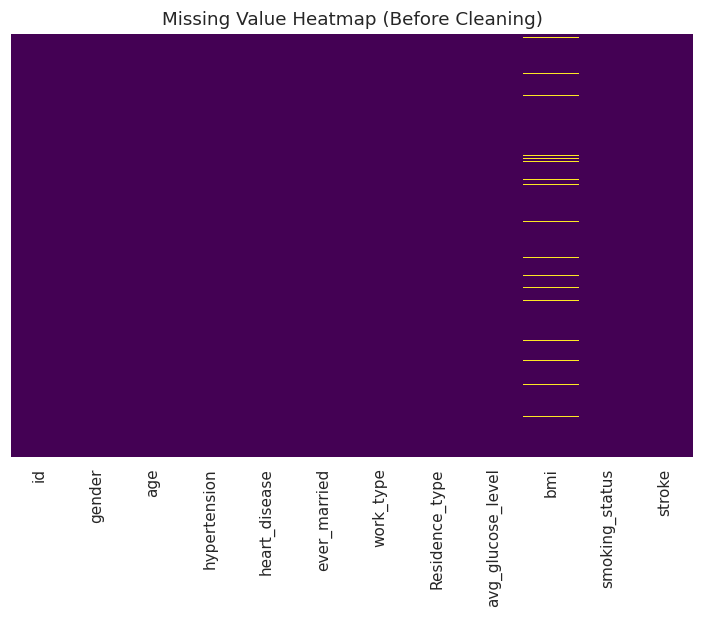

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Value Heatmap (Before Cleaning)")
plt.show()

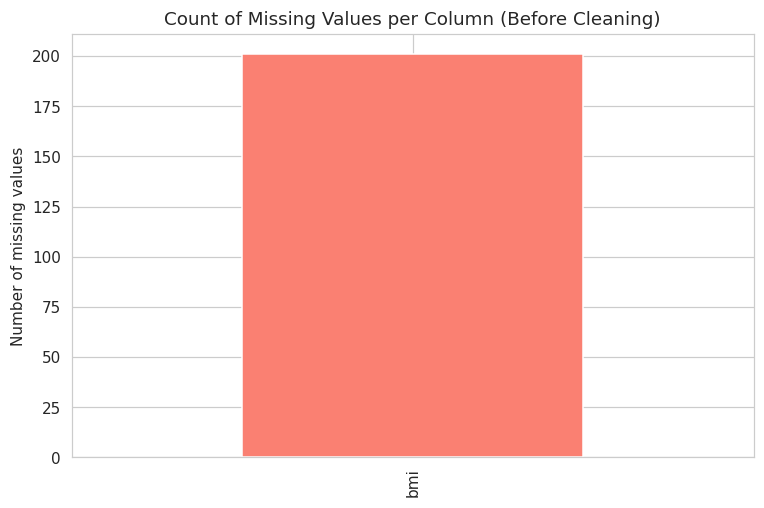

In [9]:
plt.figure(figsize=(8, 5))
missing_before[missing_before > 0].sort_values(ascending=False).plot(kind="bar", color="salmon")
plt.title("Count of Missing Values per Column (Before Cleaning)")
plt.ylabel("Number of missing values")
plt.show()

**Imputation strategy**
- `bmi` (numerical) → filled with the column **median** (robust to outliers)


In [10]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())
df["smoking_status"] = df["smoking_status"].fillna("Unknown")

print(df.isnull().sum().sum(), "missing values remain")

0 missing values remain


## 5. Handling duplicate values

In [11]:
dup_count = df.duplicated().sum()
print("Duplicate rows found:", dup_count)

df = df.drop_duplicates()
df = df.drop(columns=["id"])   # id is a unique identifier, not predictive
print("Shape after cleaning:", df.shape)

Duplicate rows found: 0
Shape after cleaning: (5110, 11)


## 6. Exploratory Data Analysis (EDA) & visualization

In [12]:
numerical_cols = ["age", "avg_glucose_level", "bmi"]
categorical_cols = ["gender", "hypertension", "heart_disease", "ever_married",
                     "work_type", "Residence_type", "smoking_status"]

### 6.1 Distribution of numerical features

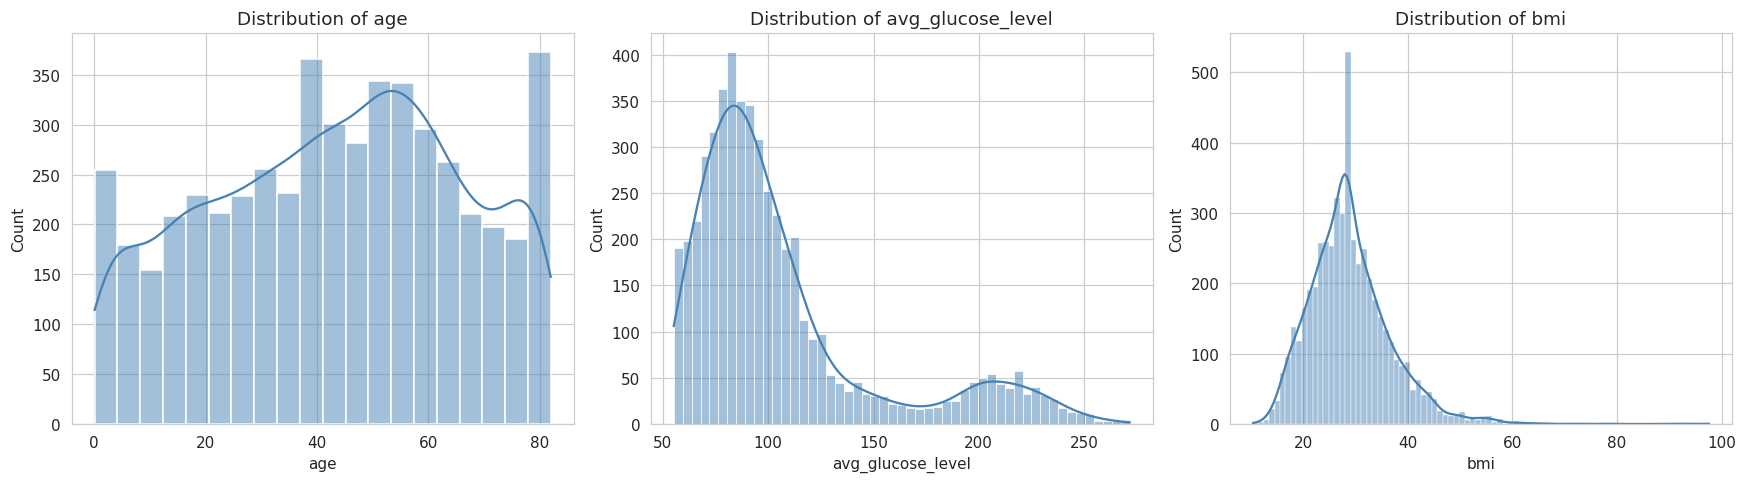

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, numerical_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### 6.2 Boxplots — outlier detection

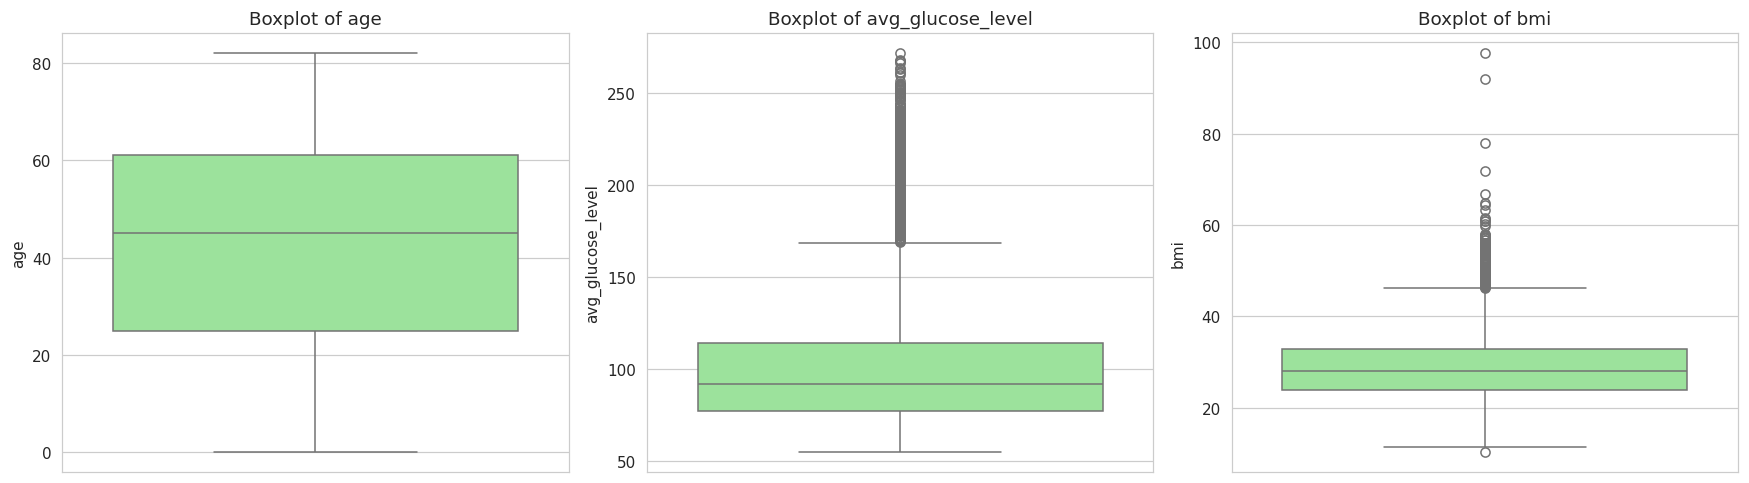

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightgreen")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

### 6.3 Categorical feature counts

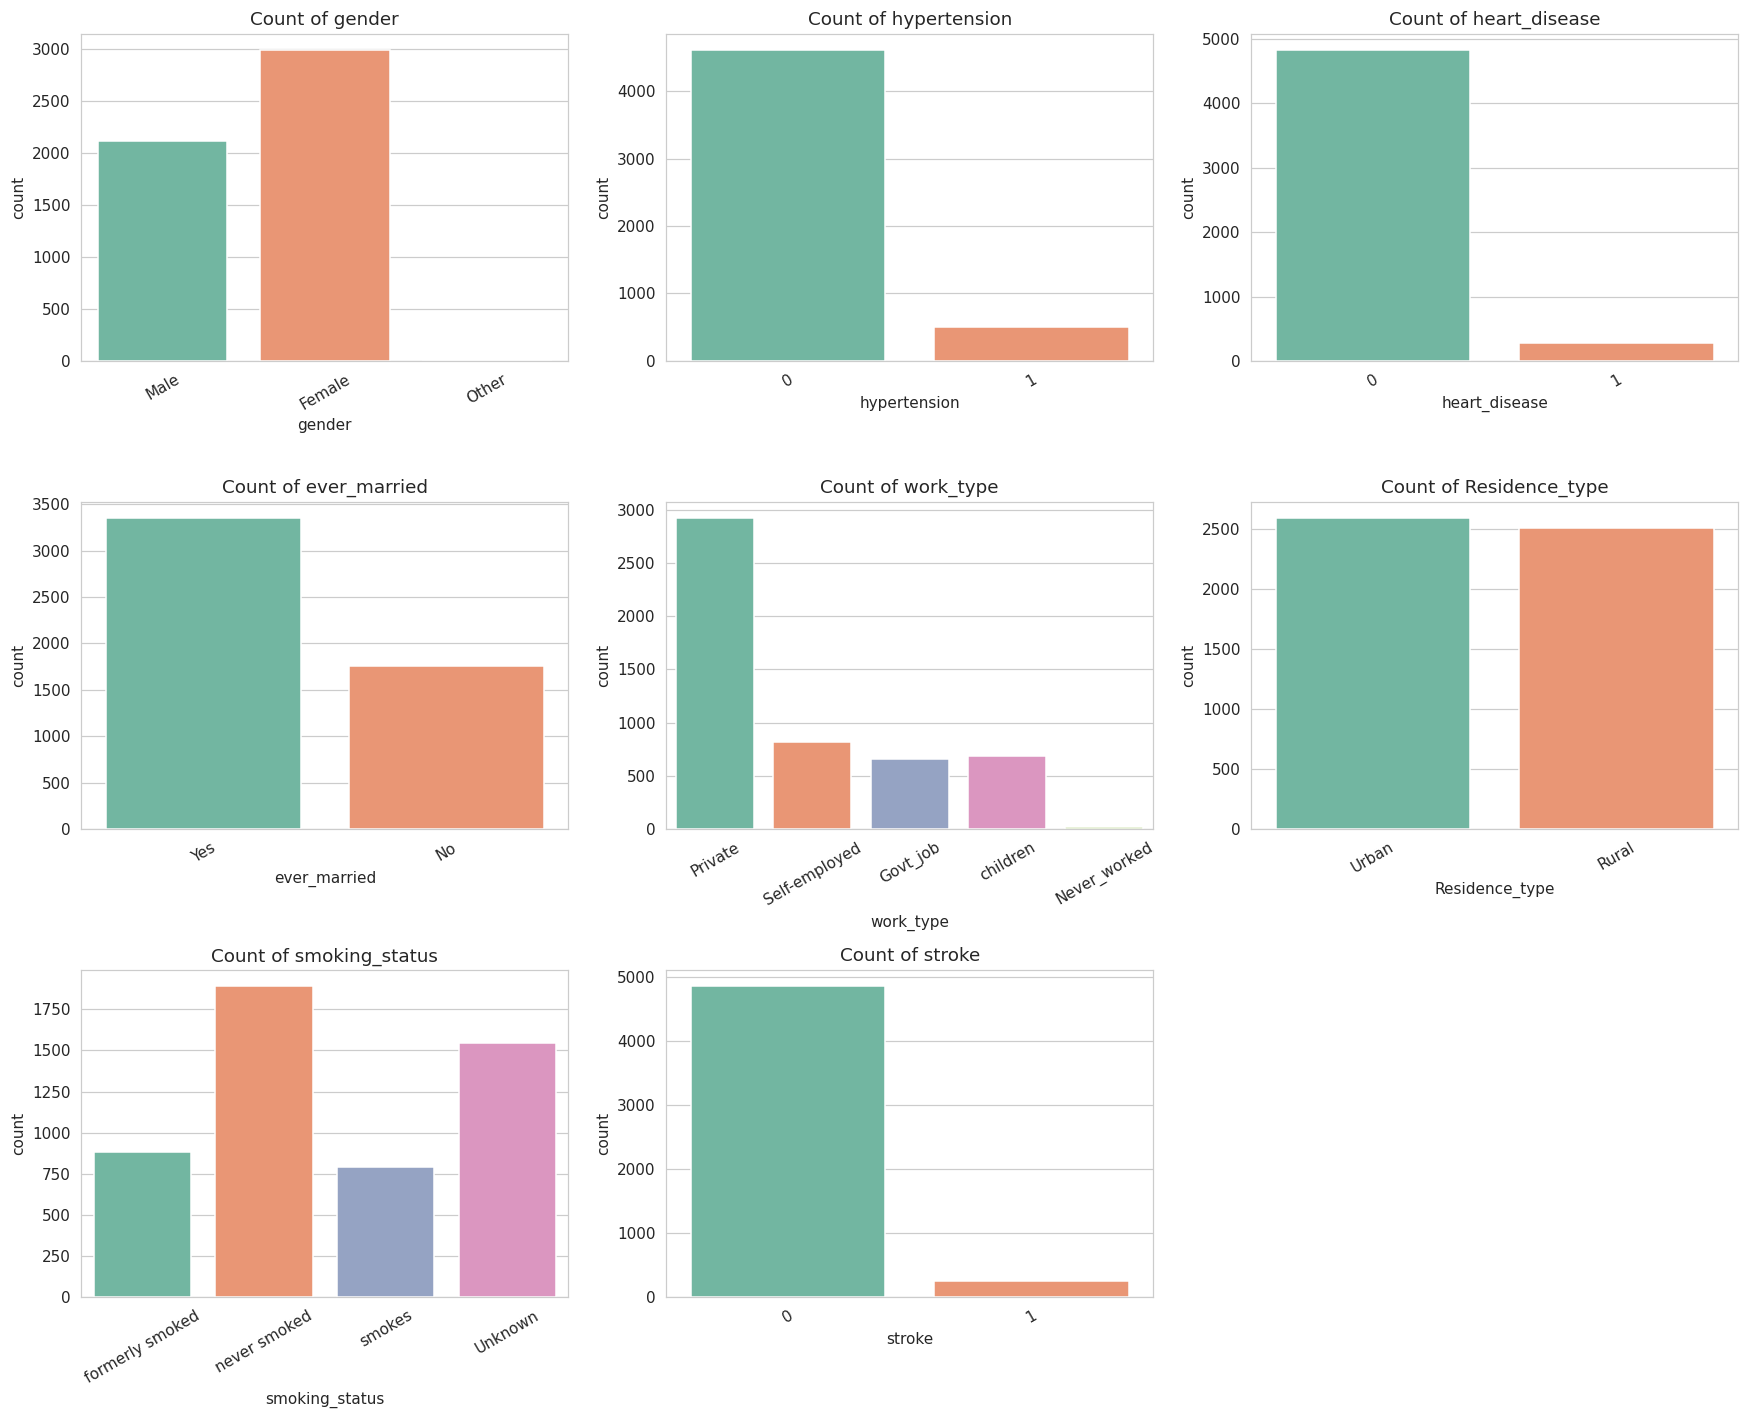

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols + ["stroke"]):
    sns.countplot(x=df[col], ax=ax, hue=df[col], palette="Set2", legend=False)
    ax.set_title(f"Count of {col}")
    ax.tick_params(axis="x", rotation=30)
for ax in axes[len(categorical_cols) + 1:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 6.4 Target class balance

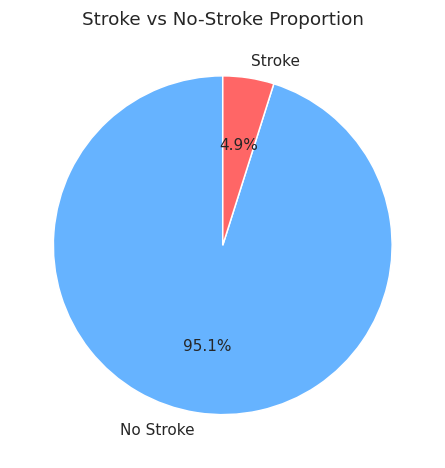

In [16]:
plt.figure(figsize=(5, 5))
df["stroke"].value_counts().plot.pie(
    labels=["No Stroke", "Stroke"], autopct="%1.1f%%",
    colors=["#66b3ff", "#ff6666"], startangle=90
)
plt.title("Stroke vs No-Stroke Proportion")
plt.ylabel("")
plt.show()

### 6.5 Numerical features vs. target

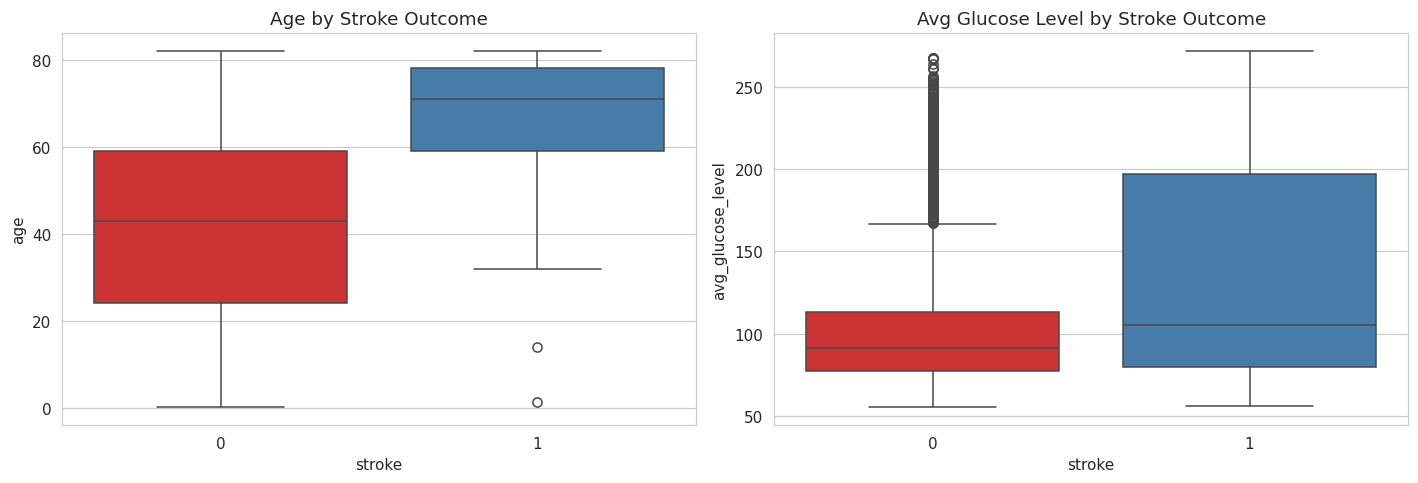

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x="stroke", y="age", data=df, hue="stroke", palette="Set1", legend=False, ax=axes[0])
axes[0].set_title("Age by Stroke Outcome")
sns.boxplot(x="stroke", y="avg_glucose_level", data=df, hue="stroke", palette="Set1", legend=False, ax=axes[1])
axes[1].set_title("Avg Glucose Level by Stroke Outcome")
plt.tight_layout()
plt.show()

## 7. Data normalization (numerical & categorical)

- **Categorical → numeric:** Label Encoding
- **Numerical → common scale:** StandardScaler (z-score); Min-Max is also shown for comparison

### 7.1 Encode categorical columns

In [18]:
df_processed = df.copy()

label_enc_cols = ["gender", "ever_married", "Residence_type", "work_type", "smoking_status"]
encoders = {}
for col in label_enc_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encoded '{col}': {encoders[col]}")

Encoded 'gender': {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Encoded 'ever_married': {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded 'Residence_type': {'Rural': np.int64(0), 'Urban': np.int64(1)}
Encoded 'work_type': {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Encoded 'smoking_status': {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}


### 7.2 Scale numerical columns

In [19]:
scaler = StandardScaler()
df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])
print(df_processed[numerical_cols].describe().loc[["mean", "std"]])

               age  avg_glucose_level           bmi
mean  5.005781e-17       1.001156e-16 -4.449583e-17
std   1.000098e+00       1.000098e+00  1.000098e+00


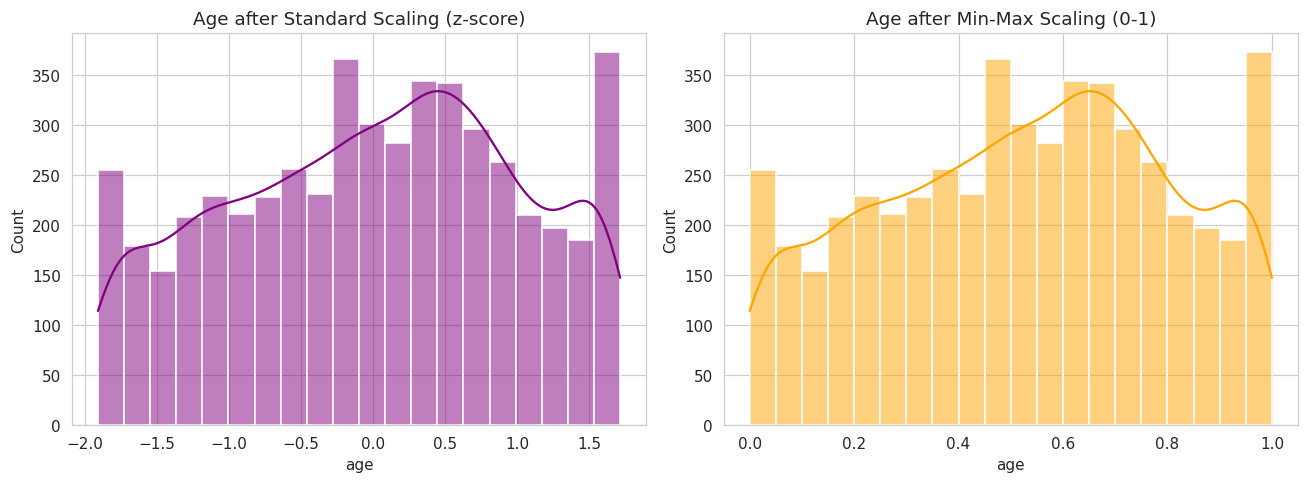

In [20]:
# Min-Max scaled version, shown only for visual comparison
minmax = MinMaxScaler()
df_minmax_demo = pd.DataFrame(minmax.fit_transform(df[numerical_cols]), columns=numerical_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_processed["age"], kde=True, ax=axes[0], color="purple")
axes[0].set_title("Age after Standard Scaling (z-score)")
sns.histplot(df_minmax_demo["age"], kde=True, ax=axes[1], color="orange")
axes[1].set_title("Age after Min-Max Scaling (0-1)")
plt.tight_layout()
plt.show()

## 8. Correlation analysis

In [21]:
corr = df_processed.corr()
print(corr["stroke"].sort_values(ascending=False))

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.036110
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
work_type           -0.032316
Name: stroke, dtype: float64


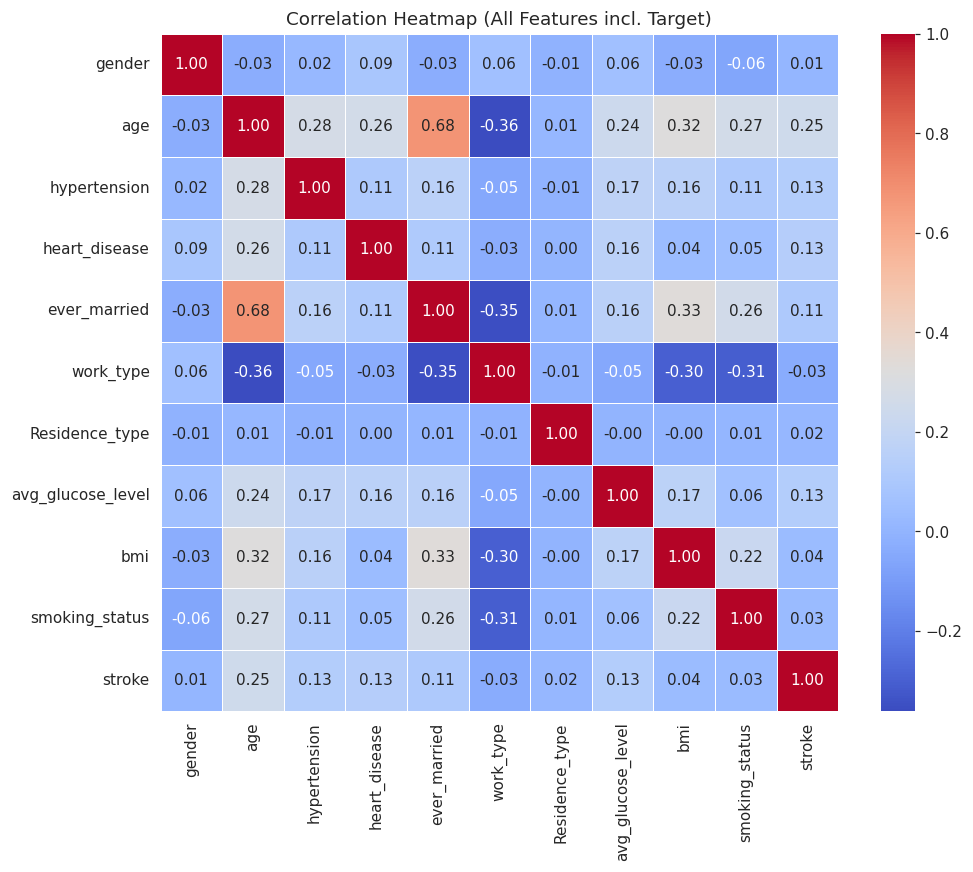

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap (All Features incl. Target)")
plt.show()

## 9. Feature selection & feature ranking

Two complementary methods:
- **ANOVA F-test** (`SelectKBest`) — statistical, univariate
- **Random Forest importance** — captures non-linear relationships & interactions

### 9.1 ANOVA F-test

In [23]:
X = df_processed.drop(columns=["stroke"])
y = df_processed["stroke"]

selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X, y)
anova_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print(anova_scores)

age                  326.916568
heart_disease         94.698406
avg_glucose_level     90.503870
hypertension          84.953542
ever_married          60.667230
bmi                    6.669168
work_type              5.340019
smoking_status         4.043033
Residence_type         1.220842
gender                 0.407266
dtype: float64


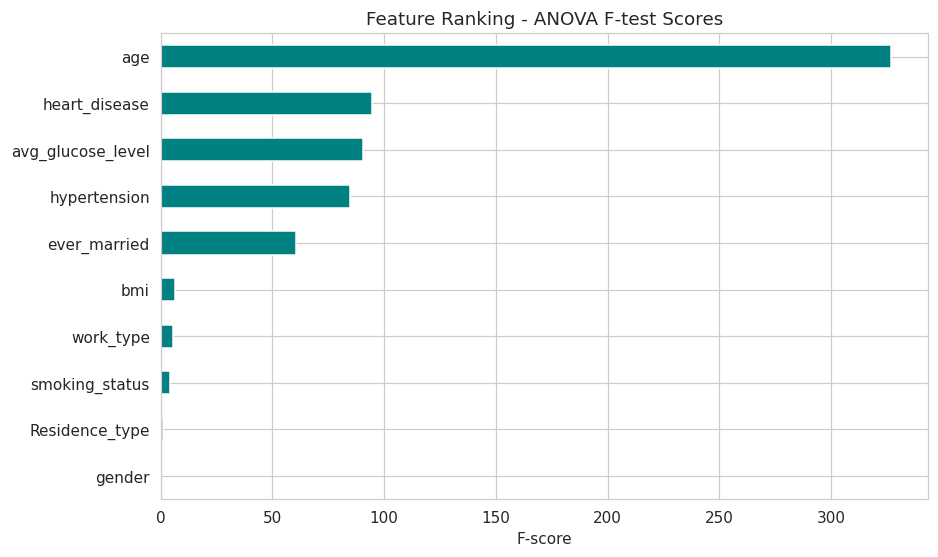

In [24]:
plt.figure(figsize=(9, 5.5))
anova_scores.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Ranking - ANOVA F-test Scores")
plt.xlabel("F-score")
plt.show()

### 9.2 Random Forest feature importance

In [25]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(rf_importance)

age                  0.383536
avg_glucose_level    0.204962
bmi                  0.183102
smoking_status       0.049362
work_type            0.048453
ever_married         0.035648
hypertension         0.030293
gender               0.021914
Residence_type       0.021584
heart_disease        0.021146
dtype: float64


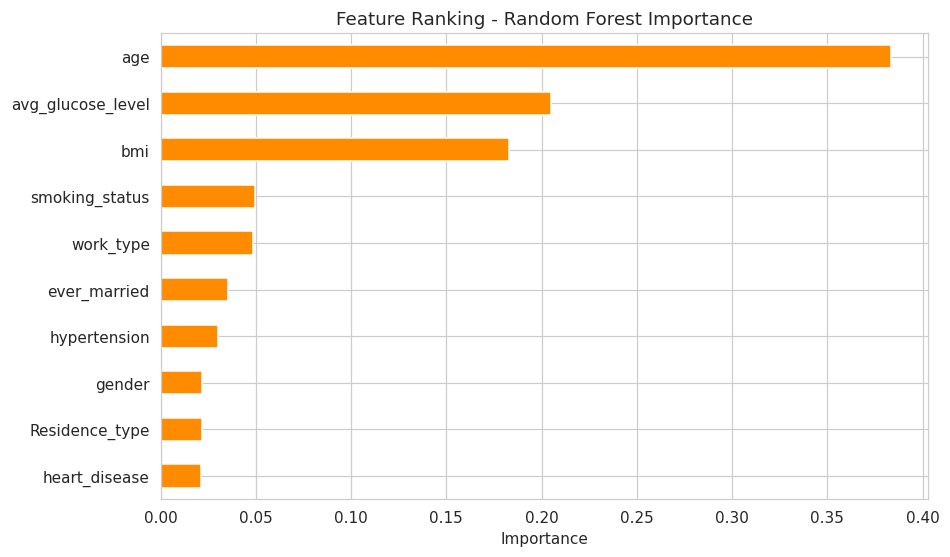

Top 6 selected features: ['age', 'avg_glucose_level', 'bmi', 'smoking_status', 'work_type', 'ever_married']


In [26]:
plt.figure(figsize=(9, 5.5))
rf_importance.plot(kind="barh", color="darkorange")
plt.gca().invert_yaxis()
plt.title("Feature Ranking - Random Forest Importance")
plt.xlabel("Importance")
plt.show()

top_features = rf_importance.head(6).index.tolist()
print("Top 6 selected features:", top_features)

## 10. Train-test split (80:20)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True) * 100)
print("\nTest target distribution:\n", y_test.value_counts(normalize=True) * 100)

X_train shape: (4088, 10)
X_test shape : (1022, 10)

Train target distribution:
 stroke
0    95.132094
1     4.867906
Name: proportion, dtype: float64

Test target distribution:
 stroke
0    95.107632
1     4.892368
Name: proportion, dtype: float64


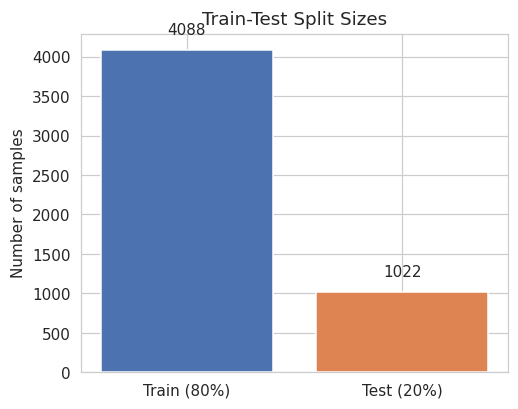

In [28]:
plt.figure(figsize=(5, 4))
plt.bar(["Train (80%)", "Test (20%)"], [len(X_train), len(X_test)], color=["#4c72b0", "#dd8452"])
plt.title("Train-Test Split Sizes")
plt.ylabel("Number of samples")
for i, v in enumerate([len(X_train), len(X_test)]):
    plt.text(i, v + 200, str(v), ha="center")
plt.show()

## 11. Save the processed dataset

Downloads `stroke_processed.csv` to your computer — ready to plug straight into a
classification model (Logistic Regression, Random Forest, XGBoost, etc.).

In [29]:
df_processed.to_csv("stroke_processed.csv", index=False)

from google.colab import files
files.download("stroke_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Note: Now We will apply Machine Learning Classifiers as per our application requirement on Processed Data (Here it is "stroke_processed.csv"). So in this Example we have complete our data preprocessing and cleaning steps by using sample stroke dataset.